线性模型
输入$\mathbf{x}=[x_1,x_2,\cdots,x_n]^T$

输出为$y=\left \langle \mathbf{x},\mathbf{w} \right \rangle +b$

$$\begin{aligned}\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b)&=\frac{1}{2 n} \sum_{i=1}^{n}\left(y_{i}-\left\langle\mathbf{x}_{i}, \mathbf{w}\right\rangle-b\right)^{2} \\ &=\frac{1}{2 n}\|\mathbf{y}-\mathbf{X} \mathbf{w}-b\|^{2}\end{aligned}$$

将bias加入$\bf w$中
$\bf x\leftarrow[x,1],w\leftarrow [w,b]$


In [21]:
import torch
from matplotlib import pyplot as plt
import numpy as np

例: $y=2x+1$

$$\mathbf{x}=[x_i,1]\\
\mathbf{y}=\mathbf{x}[a,b]$$


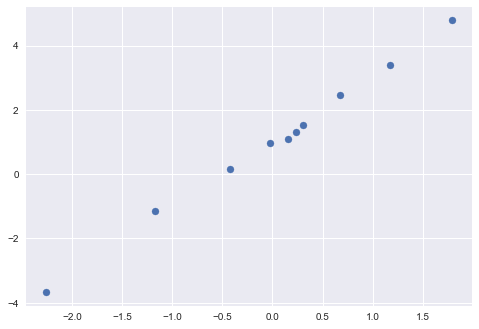

In [22]:
#构造数据集
num=10
para_num=2#参数数量(x_1,x_2,……,b)
w=torch.tensor([2.,1.])#参数数值

def train_data(num,para_num,w):
    x=torch.ones(num,para_num)
    norm_x=torch.normal(0,1,(num,para_num-1))
    x[:,:para_num-1]=norm_x[:,:para_num-1]
    y=torch.mv(x,w)+torch.normal(0,0.1,(num,1))[:,0]
    return(x,y)

a=train_data(num,para_num,w)
plt.style.use('seaborn')
fig,ax=plt.subplots()
x=a[0]
y=a[1]
ax.scatter(a[0][:,0],a[1])


In [23]:
w1=torch.rand(2,requires_grad=True)#初始
lr=0.01#学习率
epochs=100

In [24]:
# 梯度下降算法

def sgd(para_num,epochs,lr,w,x,y):
    res=torch.zeros(epochs,para_num+1)#还有loss
    for epoch in range(epochs):
        loss=(torch.mv(x,w)-y)**2#loss函数
        loss.sum().backward()
        res[epoch,:para_num]=w.detach()
        res[epoch,para_num]=loss.sum().detach()
        with torch.no_grad():#更新时不用计算梯度
            #非常重要
            w-=(w.grad)*lr
            w.grad.zero_()  
    return res
ans=sgd(2,epochs,lr,w1,x,y)
ans

tensor([[ 0.6578,  0.2050, 30.2783],
        [ 0.9938,  0.3763, 17.7370],
        [ 1.2486,  0.5104, 10.4295],
        [ 1.4418,  0.6153,  6.1687],
        [ 1.5882,  0.6975,  3.6823],
        [ 1.6991,  0.7619,  2.2303],
        [ 1.7832,  0.8124,  1.3816],
        [ 1.8469,  0.8521,  0.8850],
        [ 1.8951,  0.8832,  0.5941],
        [ 1.9316,  0.9077,  0.4235],
        [ 1.9592,  0.9269,  0.3234],
        [ 1.9801,  0.9421,  0.2645],
        [ 1.9959,  0.9540,  0.2298],
        [ 2.0079,  0.9634,  0.2094],
        [ 2.0169,  0.9708,  0.1973],
        [ 2.0237,  0.9767,  0.1902],
        [ 2.0289,  0.9813,  0.1859],
        [ 2.0328,  0.9850,  0.1834],
        [ 2.0357,  0.9878,  0.1819],
        [ 2.0379,  0.9901,  0.1810],
        [ 2.0396,  0.9919,  0.1805],
        [ 2.0408,  0.9934,  0.1802],
        [ 2.0418,  0.9945,  0.1800],
        [ 2.0425,  0.9954,  0.1798],
        [ 2.0430,  0.9961,  0.1798],
        [ 2.0434,  0.9967,  0.1797],
        [ 2.0437,  0.9971,  0.1797],
 

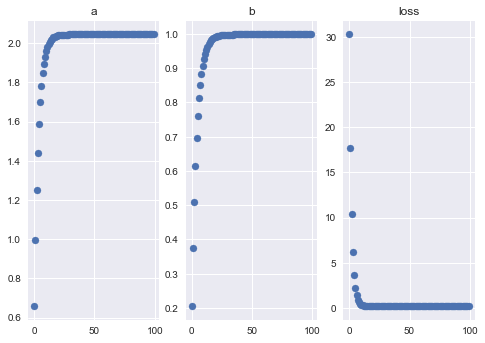

In [25]:
plt.style.use('seaborn')
fig,ax=plt.subplots(1,3)
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('loss')

for i in range(3):
    ax[i].scatter(range(epochs),[a[i] for a in ans])




$$y=2x_1-3.4x_2+4.2$$

In [26]:
para_num=3
t=train_data(10,3,torch.tensor([2.,-3.4,4.2]))


In [27]:
w1=torch.rand(para_num,requires_grad=True)#初始
lr=0.01#学习率
epochs=300

In [28]:
sgd(para_num,epochs,lr,w1,t[0],t[1])

tensor([[ 6.2039e-02,  6.4084e-01,  8.0535e-01,  2.6943e+02],
        [-1.0599e-02, -2.2165e-01,  1.4138e+00,  1.6964e+02],
        [-4.9732e-02, -8.8318e-01,  1.9119e+00,  1.0829e+02],
        ...,
        [ 1.8393e+00, -3.3673e+00,  4.1904e+00,  5.6813e-02],
        [ 1.8393e+00, -3.3673e+00,  4.1904e+00,  5.6812e-02],
        [ 1.8393e+00, -3.3673e+00,  4.1904e+00,  5.6812e-02]])

In [29]:
from torch.utils import data
#利用api简洁实现 

t=train_data(10,3,torch.tensor([2.,-3.4,4.2]))
feature,lables=t[0][:,:para_num-1],t[1].unsqueeze(-1)#去除齐次坐标

#注意unsqueeze(-1)用于从[10]升维成[10,1]

def load_array(data_array,batch_size,is_train=True):
    dataset=data.TensorDataset(*data_array)#给元组解包
    return data.DataLoader(dataset,batch_size,shuffle=is_train)#随机挑选batch_size个

batch_size=10
data_iter=load_array((feature,lables),batch_size,True)

feature.shape,lables.shape,next(iter(data_iter))

(torch.Size([10, 2]),
 torch.Size([10, 1]),
 [tensor([[-1.7321,  0.7037],
          [ 0.7857, -2.1776],
          [ 1.2220, -0.4672],
          [-0.8538,  0.3571],
          [-0.2449,  1.6149],
          [-1.7532, -1.4014],
          [-0.6936,  0.6568],
          [ 0.0852, -0.3679],
          [ 1.3626, -0.1113],
          [ 1.8560,  1.4337]]),
  tensor([[-1.5709],
          [13.0679],
          [ 8.2589],
          [ 1.1938],
          [-1.6689],
          [ 5.3352],
          [ 0.4670],
          [ 5.6813],
          [ 7.4081],
          [ 3.1335]])])

In [30]:
from torch import nn

net=nn.Sequential(nn.Linear(2,1))#输入为2,输出为1
#放在序列内

In [31]:
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [32]:
loss=nn.MSELoss()#Mean Square Error

#实例化Stochastic Gradient Descent(SGD)随机梯度下降
trainer=torch.optim.SGD(net.parameters(),lr=0.03)

for epoch in range(epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(feature), lables)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 32.255848
epoch 2, loss 27.980682
epoch 3, loss 24.283922
epoch 4, loss 21.085667
epoch 5, loss 18.317282
epoch 6, loss 15.919786
epoch 7, loss 13.842451
epoch 8, loss 12.041635
epoch 9, loss 10.479767
epoch 10, loss 9.124495
epoch 11, loss 7.947927
epoch 12, loss 6.926024
epoch 13, loss 6.038045
epoch 14, loss 5.266089
epoch 15, loss 4.594696
epoch 16, loss 4.010510
epoch 17, loss 3.501983
epoch 18, loss 3.059128
epoch 19, loss 2.673305
epoch 20, loss 2.337031
epoch 21, loss 2.043826
epoch 22, loss 1.788072
epoch 23, loss 1.564902
epoch 24, loss 1.370090
epoch 25, loss 1.199969
epoch 26, loss 1.051359
epoch 27, loss 0.921491
epoch 28, loss 0.807964
epoch 29, loss 0.708689
epoch 30, loss 0.621848
epoch 31, loss 0.545859
epoch 32, loss 0.479346
epoch 33, loss 0.421108
epoch 34, loss 0.370102
epoch 35, loss 0.325417
epoch 36, loss 0.286258
epoch 37, loss 0.251933
epoch 38, loss 0.221836
epoch 39, loss 0.195440
epoch 40, loss 0.172285
epoch 41, loss 0.151967
epoch 42, loss 0

In [33]:
net[0].weight.data,net[0].bias.data

(tensor([[ 2.0305, -3.3512]]), tensor([4.2044]))